In [1]:
# Importer les packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

### <font color = 'bisque'>Importer et lire des données

In [2]:
# Import les données
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [3]:
# chemin à l'emplacement  du fichier
df = pd.read_csv("/content/drive/MyDrive/apprentissage_supervisé_aihub/Regression/Doc 1/Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
# Afficher les infos des données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


### <font color = 'bisque'>Exploration et préparation des données

In [5]:
# sélection les variables quantitatives
quant_data = df.select_dtypes(include='number')
quant_data.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0


In [6]:
# décrire les variables quantitatives
quant_data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


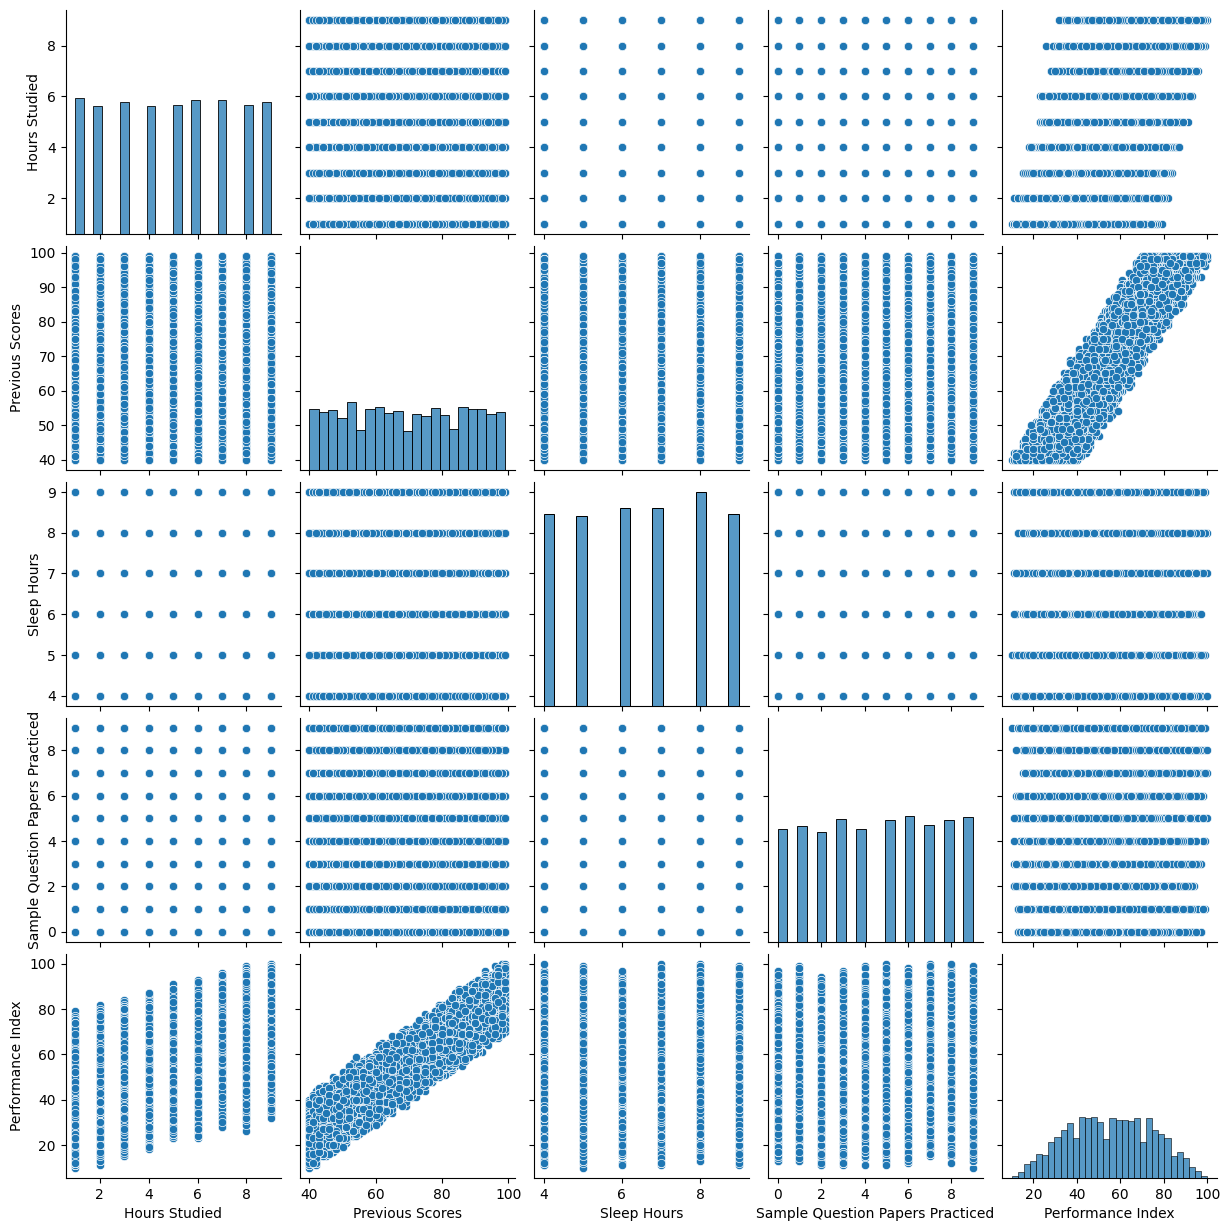

In [7]:
# pairplot des variables quantitatives
sns.pairplot(quant_data)
plt.show()

In [8]:
# Fonction permettant de visualiser les boxplots
def boxplot_func(col):
    fig = px.box(df,x = col)
    fig.show()

In [9]:
# Appliquer la fonctions boxplot_func
for col in quant_data.columns:
  boxplot_func(col)

In [10]:
# Afficher la matrice de corrélation
corr = quant_data.corr()
corr

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


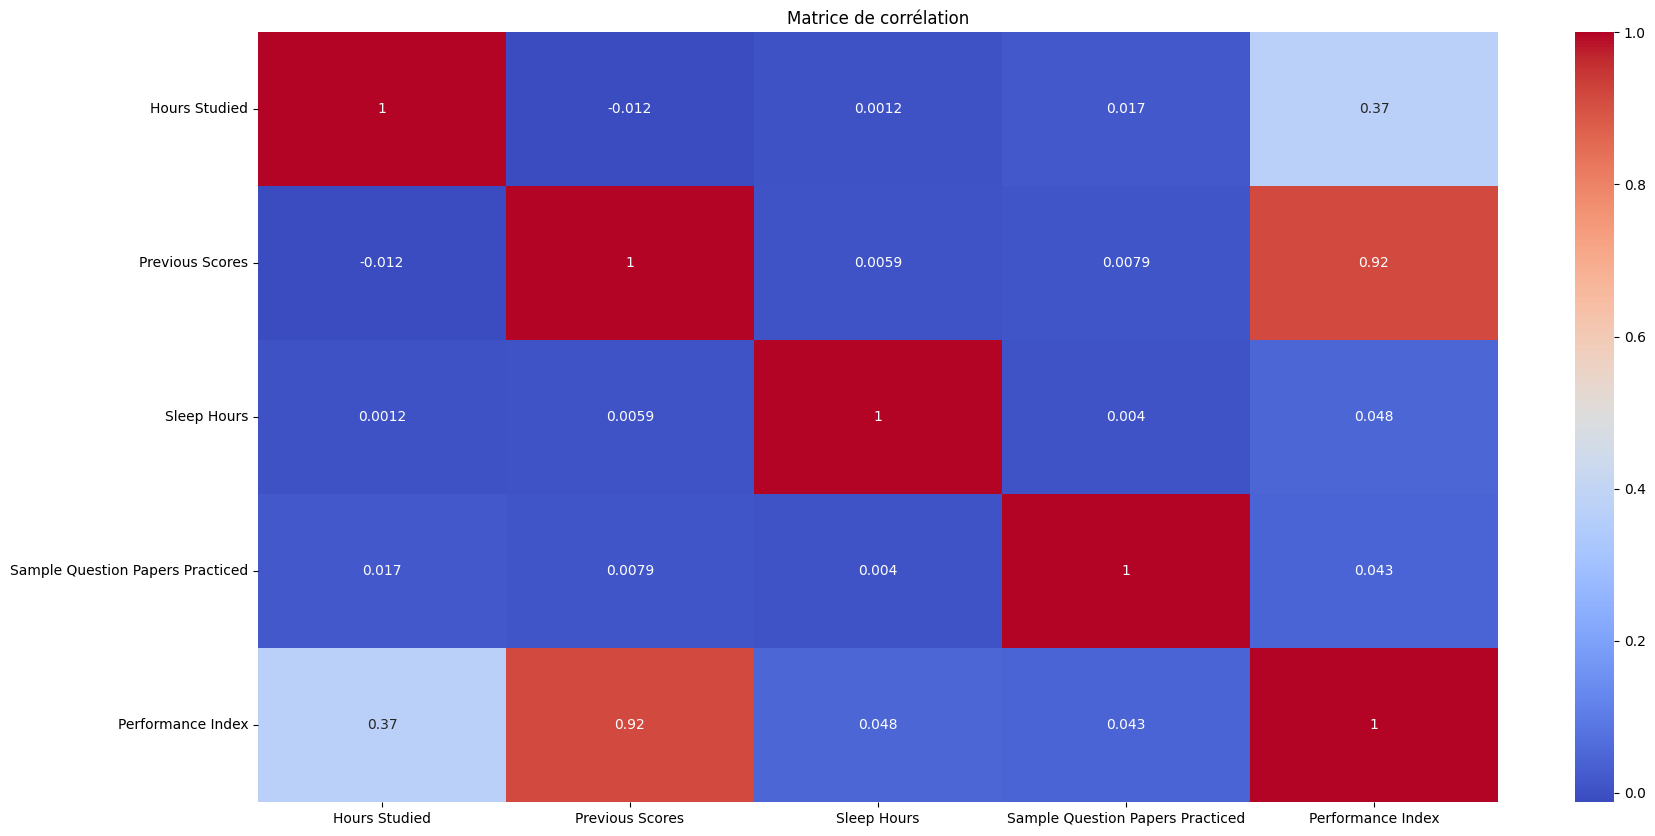

In [11]:
# Visualisaton le matrice de corrélation
plt.figure(figsize = (20, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation')
plt.show()

In [12]:
# sélection les variables catégorielles
cat_data = df.select_dtypes(include='object')
cat_data.head()

,Extracurricular Activities
0,Yes
1,No
2,Yes
3,Yes
4,No


In [13]:
# décrire les variables catégorielles
cat_data.describe()

,Extracurricular Activities
count,10000
unique,2
top,No
freq,5052


In [14]:
# Fonction de visualisaion du counplot
def countplot_func(col):
    val = cat_data[col].value_counts()
    fig = px.bar(x = val.index, y = val.values,color = val.index.astype(str), text_auto = True)
    fig.show()

In [15]:
# Appliquer la fonction countplot_func
for col in cat_data.columns:
  countplot_func(col)

In [16]:
# Encoder la variable Extracurricular Activities
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Extracurricular Activities'] = encoder.fit_transform(df['Extracurricular Activities'])
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [17]:
# Fractionner les données en variables prédicteurs (x) et variable cible (y)
# la variable cible est Performance Index (dernière colonne)
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [18]:
# importer StandardScaler
from sklearn.preprocessing import RobustScaler
# Normaliser x
import joblib as jb
scaler = RobustScaler()
x = scaler.fit_transform(x)
jb.dump(scaler, 'scaler.joblib')
jb.dump(encoder, 'encoders.joblib')
x[:5]

array([[ 0.5       ,  0.96774194,  1.        ,  0.66666667, -0.8       ],
       [-0.25      ,  0.41935484,  0.        , -1.        , -0.6       ],
       [ 0.75      , -0.58064516,  1.        ,  0.        , -0.6       ],
       [ 0.        , -0.5483871 ,  1.        , -0.66666667, -0.6       ],
       [ 0.5       ,  0.19354839,  0.        ,  0.33333333,  0.        ]])

In [19]:
from sklearn.model_selection import train_test_split
# Splitter les données en train, val et test
x_train, x_vt,y_train,y_vt = train_test_split(x,y , test_size = 0.2, random_state = 42)
# Splitter les données en val et test
x_val, x_test, y_val, y_test = train_test_split(x_vt, y_vt, test_size = 0.5, random_state = 42)

### <font color = 'bisque'>Multiple Linear Regression<font>

In [20]:
# Rechercher les paramètres optimaux de l'algorithme
from sklearn.model_selection import GridSearchCV
# Importer Linear Regression
from sklearn.linear_model import LinearRegression
# dictionnaire params
params = {'fit_intercept': [True,False],
               'positive': [True,False]}
# Initialisation du modèle
lr = LinearRegression()
# Initialisation du GridSearchCV
grid_ = GridSearchCV(lr, params, cv = 5)
# Lancer la recherche
grid_.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]})

In [21]:
# afficher les paramètres optimaux
print(grid_.best_params_)

# Entrainer la Linear Regression en utilisant les paramètres optimaux
lr_model = LinearRegression(**grid_.best_params_)
lr_model.fit(x_train, y_train)

{'fit_intercept': True, 'positive': True}


LinearRegression(positive=True)

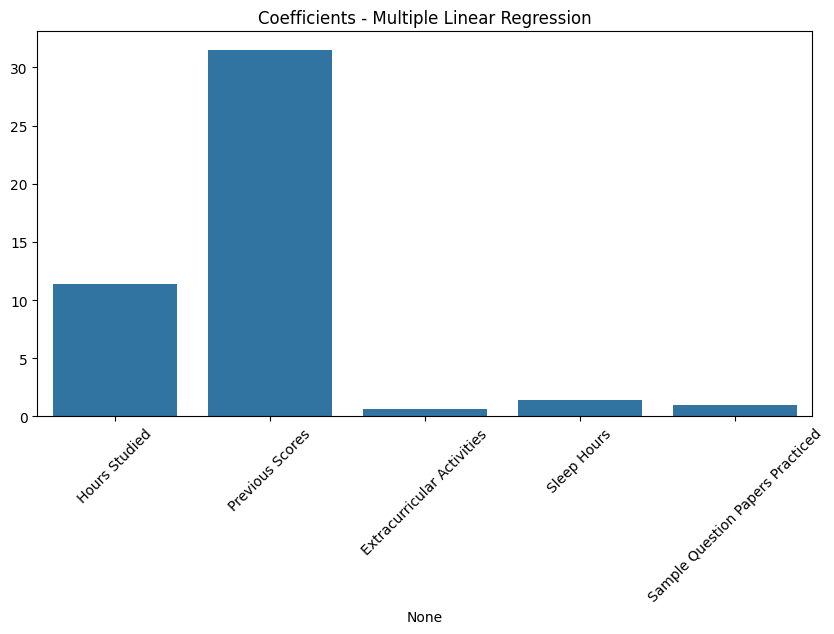

In [22]:
# Visualiser les coefs des variables à travers un barplot
plt.figure(figsize=(10,5))
sns.barplot(x=df.columns[:-1], y=lr_model.coef_)
plt.xticks(rotation=45)
plt.title("Coefficients - Multiple Linear Regression")
plt.show()

#### <font color = 'teal'> Evaluation du linear regression<font>

In [23]:
from sklearn.metrics import r2_score, mean_squared_error
# Calculer le R2 score et Mean Squarred Error sur les données de validation
y_pred = lr_model.predict(x_val)
r2_lr = r2_score(y_val, y_pred)
mse_lr = mean_squared_error(y_val, y_pred)
print(f"R2 : {r2_lr: .3f} --- MSE : {mse_lr: .3f}")

R2 :  0.989 --- MSE :  4.159


In [24]:
# Calculer le R2 score sur les données d'entrainement
y_pred_train = lr_model.predict(x_train)
print(f"R2 train : {r2_score(y_train, y_pred_train): .3f}")

R2 train :  0.989


### <font color = 'bisque'>Ridge Regression

In [25]:
# Rechercher les paramètres optimaux de l'algorithme
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
# dictionnaire params
params = {
    'alpha':np.logspace(-8,8, 100)
}
# Initialisation du modèle
rr = Ridge()
# Initialisation du GridSearchCV
grid_ = GridSearchCV(rr, params, cv = 5)
# Lancer la recherche
grid_.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': array([1.00000000e-08, 1.45082878e-08, 2.10490414e-08, 3.05385551e-08,
       4.43062146e-08, 6.42807312e-08, 9.32603347e-08, 1.35304777e-07,
       1.96304065e-07, 2.84803587e-07, 4.13201240e-07, 5.99484250e-07,
       8.69749003e-07, 1.26185688e-06, 1.83073828e-06, 2.65608778e-06,
       3.85352859e-06, 5.59081018e-06, 8.11130831e-06, 1....
       1.91791026e+04, 2.78255940e+04, 4.03701726e+04, 5.85702082e+04,
       8.49753436e+04, 1.23284674e+05, 1.78864953e+05, 2.59502421e+05,
       3.76493581e+05, 5.46227722e+05, 7.92482898e+05, 1.14975700e+06,
       1.66810054e+06, 2.42012826e+06, 3.51119173e+06, 5.09413801e+06,
       7.39072203e+06, 1.07226722e+07, 1.55567614e+07, 2.25701972e+07,
       3.27454916e+07, 4.75081016e+07, 6.89261210e+07, 1.00000000e+08])})

In [26]:
# Afficher le best paramètre
grid_.best_params_

{'alpha': np.float64(1e-08)}

In [27]:
# Initialisation du modèle avec l'alpha optimal
ridge_model = Ridge(alpha=grid_.best_params_['alpha'])
ridge_model.fit(x_train, y_train)

Ridge(alpha=np.float64(1e-08))

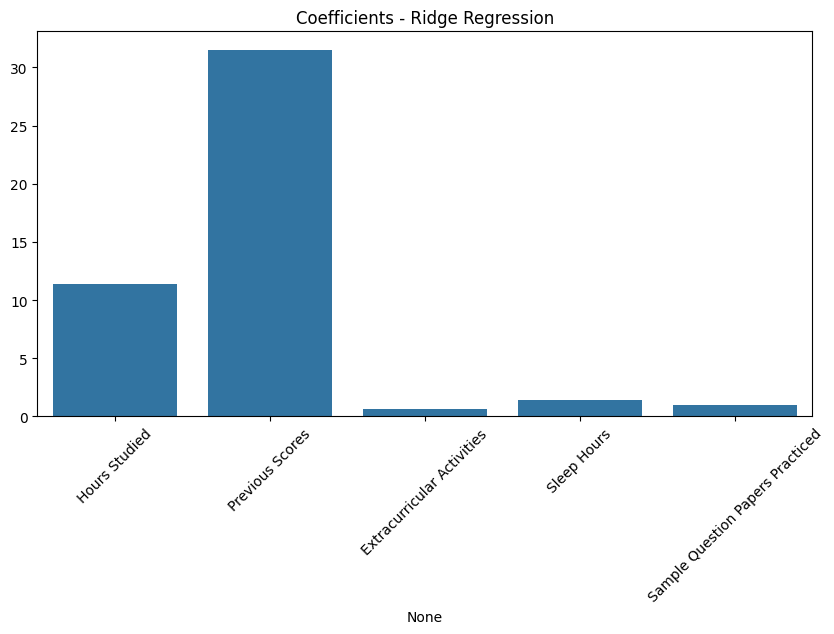

In [28]:
# Visualiser les coefs des variables à travers un barplot
plt.figure(figsize=(10,5))
sns.barplot(x=df.columns[:-1], y=ridge_model.coef_)
plt.xticks(rotation=45)
plt.title("Coefficients - Ridge Regression")
plt.show()

#### <font color = 'teal'> Evaluation du Ridge Regression<font>

In [30]:
# Calculer le R2 score et Mean Squarred Error
y_pred = ridge_model.predict(x_val)
r2_ridge = r2_score(y_val, y_pred)
mse_ridge = mean_squared_error(y_val, y_pred)
print(f"R2 : {r2_ridge: .3f} --- MSE : {mse_ridge: .3f}")

R2 :  0.989 --- MSE :  4.159


In [31]:
# Calculer le R2 score sur les données d'entrainement
y_pred_train = ridge_model.predict(x_train)
print(f"R2 train : {r2_score(y_train, y_pred_train): .3f}")

R2 train :  0.989


### <font color = 'bisque'>Lasso Regression<font>

In [32]:
# Rechercher les paramètres optimaux de l'algorithme
from sklearn.linear_model import Lasso
# dictionnaire params
params = {
    'alpha':np.logspace(-8,8, 100)
}
# Initialisation du modèle
lr = Lasso()
# Initialisation du GridSearchCV
grid__ = GridSearchCV(lr, params, cv = 5)
# Lancer la recherche
grid__.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': array([1.00000000e-08, 1.45082878e-08, 2.10490414e-08, 3.05385551e-08,
       4.43062146e-08, 6.42807312e-08, 9.32603347e-08, 1.35304777e-07,
       1.96304065e-07, 2.84803587e-07, 4.13201240e-07, 5.99484250e-07,
       8.69749003e-07, 1.26185688e-06, 1.83073828e-06, 2.65608778e-06,
       3.85352859e-06, 5.59081018e-06, 8.11130831e-06, 1....
       1.91791026e+04, 2.78255940e+04, 4.03701726e+04, 5.85702082e+04,
       8.49753436e+04, 1.23284674e+05, 1.78864953e+05, 2.59502421e+05,
       3.76493581e+05, 5.46227722e+05, 7.92482898e+05, 1.14975700e+06,
       1.66810054e+06, 2.42012826e+06, 3.51119173e+06, 5.09413801e+06,
       7.39072203e+06, 1.07226722e+07, 1.55567614e+07, 2.25701972e+07,
       3.27454916e+07, 4.75081016e+07, 6.89261210e+07, 1.00000000e+08])})

In [33]:
# Afficher l'alpha optimal
grid__.best_params_

{'alpha': np.float64(0.00023101297000831627)}

In [34]:
# Initialiser le modèle
lasso_model = Lasso(alpha=grid__.best_params_['alpha'])
lasso_model.fit(x_train, y_train)

Lasso(alpha=np.float64(0.00023101297000831627))

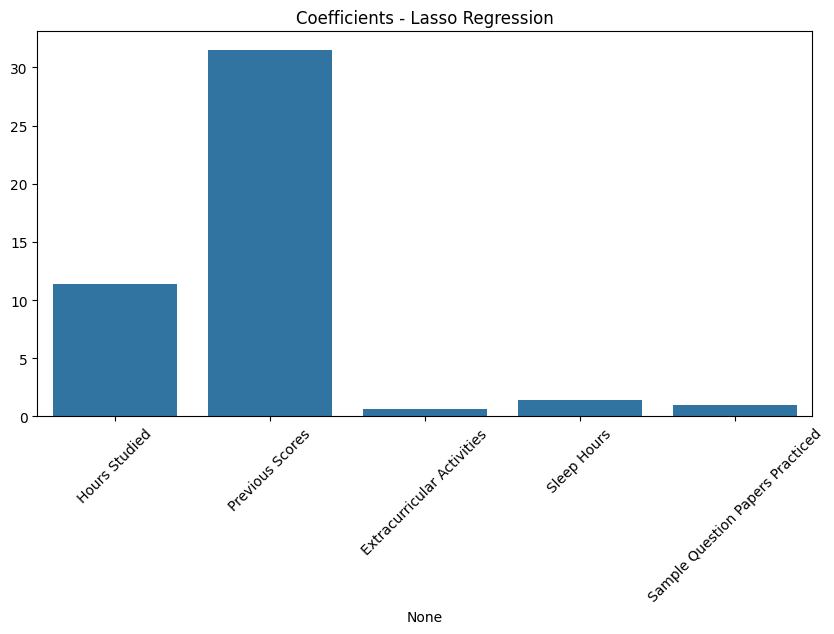

In [35]:
# Visualiser les coefs des variables à travers un barplot
plt.figure(figsize=(10,5))
sns.barplot(x=df.columns[:-1], y=lasso_model.coef_)
plt.xticks(rotation=45)
plt.title("Coefficients - Lasso Regression")
plt.show()

#### <font color = 'teal'> Evaluation du Lasso Regression<font>

In [36]:
# Calculer le R2 score et Mean Squarred Error
y_pred = lasso_model.predict(x_val)
r2_lasso = r2_score(y_val, y_pred)
mse_lasso = mean_squared_error(y_val, y_pred)
print(f"R2 : {r2_lasso: .3f} --- MSE : {mse_lasso: .3f}")

R2 :  0.989 --- MSE :  4.159


In [37]:
# Calculer le R2 score sur les données train
y_pred_train = lasso_model.predict(x_train)
print(f"R2 train : {r2_score(y_train, y_pred_train): .3f}")

R2 train :  0.989


### <font color = 'bisque'>Decision Tree Regressor<font>

In [38]:
# Recherche des paramètres optimaux du decision tree
from sklearn.tree import DecisionTreeRegressor
# Dictionaire des params
params = {
    'max_depth':np.arange(1,15),
    'criterion':['squared_error', 'absolute_error']
}
# Initialisation du modèle
dt = DecisionTreeRegressor()
# Initialisation du GridSearchCV
grid___ = GridSearchCV(dt, params, cv = 5)
# Lancer la recherche
grid___.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])})

In [39]:
# Afficher les paramètres optimaux
grid___.best_params_

{'criterion': 'squared_error', 'max_depth': np.int64(9)}

In [40]:
# Entrainer le modèle decision tree sur les paramètres optimaux
dt_model = DecisionTreeRegressor(**grid___.best_params_)
dt_model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=np.int64(9))

#### <font color = 'teal'> Evaluation du Decision Tree<font>

In [41]:
# Calculer le R2 score et Mean Squarred Error
y_pred = dt_model.predict(x_val)
r2_dt = r2_score(y_val, y_pred)
mse_dt = mean_squared_error(y_val, y_pred)
print(f"R2 : {r2_dt: .3f} --- MSE : {mse_dt: .3f}")

R2 :  0.985 --- MSE :  5.603


In [42]:
# Calculer le R2 score sur les données train
y_pred_train = dt_model.predict(x_train)
print(f"R2 train : {r2_score(y_train, y_pred_train): .3f}")

R2 train :  0.989


### <font color = 'bisque'>Tester le modèle le plus performant<font>

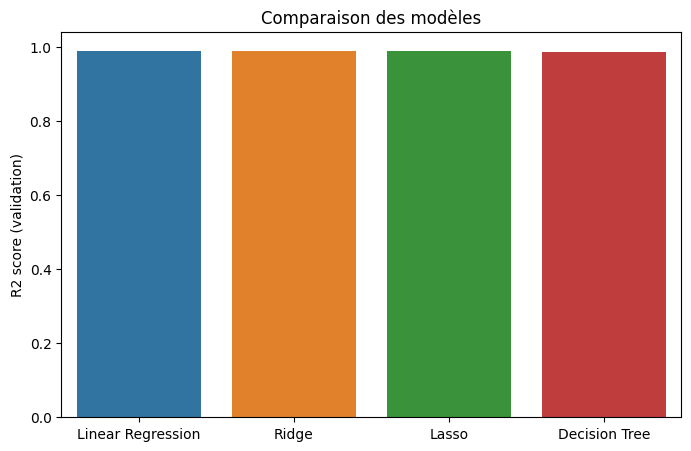

In [43]:
# Diagramme en barre de comparaison de tous les modèles (R2 sur validation)
list_r2 = [r2_lr, r2_ridge, r2_lasso, r2_dt]
list_names = ['Linear Regression', 'Ridge', 'Lasso', 'Decision Tree']
plt.figure(figsize=(8,5))
sns.barplot(x=list_names, y=list_r2, hue=list_names)
plt.ylabel('R2 score (validation)')
plt.title('Comparaison des modèles')
plt.show()

In [44]:
# Sélection automatique du meilleur modèle (le plus grand R2 sur la validation)
models = {'Linear Regression': lr_model, 'Ridge': ridge_model, 'Lasso': lasso_model, 'Decision Tree': dt_model}
scores_r2 = dict(zip(list_names, list_r2))

best_name = max(scores_r2, key=scores_r2.get)
best_model = models[best_name]

print(f"Meilleur modèle (sur la validation, R2) : {best_name}  --  R2 = {scores_r2[best_name]: .3f}")

Meilleur modèle (sur la validation, R2) : Lasso  --  R2 =  0.989


In [45]:
# Evaluation finale du meilleur modèle sur les données test (jamais vues)
y_pred_test = best_model.predict(x_test)
r2_test = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
print(f"[{best_name}] R2 test : {r2_test: .3f} --- MSE test : {mse_test: .3f}")

[Lasso] R2 test :  0.989 --- MSE test :  4.006


In [46]:
# télécharger le meilleur modèle
jb.dump(best_model, 'best_model.joblib')
print(f"Modèle sauvegardé dans best_model.joblib : il s'agit du modèle {best_name}")

Modèle sauvegardé dans best_model.joblib : il s'agit du modèle Lasso
